<span style="color:gray;">Deep learning >> Redes Convolucionales CNN</span>
<h1 style="margin-top:3px;">Redes Neuronales Convoluciones</h1>
<p>Las redes convolucionales, también conocidas como redes neuronales convolucionales, (o convolutional neural networks <b>CNN</b> o <b>ConvNet</b>) , son un tipo especializado de red neuronal para procesar datos que tienen una topología similar a una cuadrícula. Los ejemplos incluyen datos de series temporales o audio, que se pueden considerar como una cuadrícula <b>1-D</b> que toma muestras a intervalos de tiempo regulares, y datos de imágenes, que se pueden considerar como una cuadrícula <b>2-D</b> de píxeles.</p>

<p>El uso de redes densas para procesar imagenes ignora una propiedad clave de éstas, que es que los píxeles cercanos están más fuertemente correlacionados que los píxeles más distantes. Muchos de los enfoques modernos de la visión por computadora explotan esta propiedad al extraer características locales que dependen solo de pequeñas subregiones de la imagen. La información de dichas características se puede fusionar en etapas posteriores de procesamiento para detectar características de orden superior y, en última instancia, generar información sobre la imagen en su conjunto. Además, es probable que las características locales, que son útiles en una región de la imagen, lo sean en otras regiones de la imagen, por ejemplo, si se traslada el objeto de interés.</p>

<p>Las ConvNet se diseñaron para procesar imágenes y tratan de simular el funcionamiento de la visión humana. Restringen la arquitectura para usar un conjunto de pesos más reducido. En particular, a diferencia de una red neuronal normal, las capas ConvNet tienen neuronas dispuestas en 3 dimensiones: ancho, alto, profundidad (se adoptan las iniciales en inglés $w, h, d$). En las redes neuronales densas se tiene una matriz de pesos ($m, n$) para conectar una capa anterior de $m$ neuronas con una de $n$. Aquí se conectarán las $n$ neuronas con $d$ capas convolucionales usando un bloque de ($w, h, d$) pesos. La reducción de complejidad viene dado porque la dimensión de ($w, h$) es muy inferior a ($m, n$).</p>

<p>Una operación de <b>convolución</b> básica que se aplica a una imagen bidimensional I como entrada, usando un kernel o <b>filtro</b> K bidimensional y que nos da como resultado una nueva imagen S sería por ejemplo:</p>
$$S(i, j)=(K*I)(i, j)=\sum_m \sum_n= I(m,n)K(i-m, j-n)$$

<p>Las redes neuronales convolucionales modelan de forma consecutiva pequeñas piezas de información, tratando de extraer información sobre diferentes patrones de cada imagen. La primera capa intentará detectar los <b>bordes</b> y establecer patrones de detección de bordes, por ejemplo. Todo ello en una secuencia de mapas que constituirán el primer bloque de convolución. Luego, en secuencia de capas posteriores trataran de combinarlos en formas más simples y, finalmente, en patrones de las diferentes posiciones de los objetos, <b>iluminación</b>, <b>escalas</b>, etc. Las capas finales intentarán hacer coincidir una imagen de entrada con todos los patrones y llegar a una predicción final como una suma ponderada de todos ellos, usando ya una red densa.</p>

<img src="img/Densa_vs_ConvNet.png" width="640" style="margin: 0 auto" />
<p><b>Izquierda:</b> Una red neuronal normal de 3 capas. <b>Derecha</b>: Un ConvNet organiza sus neuronas en tres dimensiones (ancho, alto, profundidad), como se visualiza en una de las capas. Cada capa de un ConvNet transforma el volumen de entrada 3D en un volumen de salida 3D de activaciones neuronales. En este ejemplo, la capa de entrada roja contiene la imagen, por lo que su ancho y alto serían las dimensiones de la imagen, y la profundidad sería de 3 (canales rojo, verde, azul).</p>

<p>Una Arquitectura Convolucional tipo estará compuesta por las capas: [INPUT - CONV - RELU - POOL - FC]. Cuyo detalle es:</p>
<ul>
    <li><b>INPUT [bxhx3]</b> contendrá los valores de píxeles raw de la imagen, en este caso una imagen de ancho b, altura h, y con tres canales de color R, G, B.</li>
    <li><b>La capa CONV</b> calculará la salida de las neuronas que están conectadas a las regiones locales en la entrada, cada una calculando un producto de punto entre sus pesos y una pequeña región a la que están conectadas en el volumen de entrada. Esto puede resultar en un volumen como [BxHxd] si decidimos usar d filtros. Los pesos que conectan los pixels localmente son compartidos y son aprendibles.</li>
    <li>La capa <B>RELU</B> aplicará una función de activación por elementos, como el umbral <b>(max(0,x))</b> en cero. Esto deja el tamaño del volumen sin cambios ([BxHxd]).</li>
    <li>La capa <b>POOL</b> realizará una operación de downsampling a lo largo de las dimensiones espaciales (ancho, alto), lo que dará como resultado un volumen como [bxhxd], siendo (b,h) inferiores a (B,H). Esta capa no utiliza pesos aprendibles.</li>
    <li>La capa <b>FC o densa</b> (es decir, totalmente conectada) calculará los puntajes de clase, lo que resultará en un volumen de tamaño [1x1xK], donde cada uno de los K números corresponde a un puntaje de clase, entre las K categorías del conjunto. Al igual que con las redes neuronales ordinarias y como su nombre indica, cada neurona en esta capa estará conectada a todos los números en el volumen anterior.</li>
</ul>

<h2>Reglas generales para modelar una red convolucional</h2>
<p>La <b>capa de entrada</b> (que contiene la imagen) debe ser divisible por $2^n$. Los números comunes incluyen 32 (por ejemplo, CIFAR-10), 64, 96 (por ejemplo, STL-10) o 224 (por ejemplo, ImageNet), 384 y 512.</p>
<p>Las capas <b>conv</b> deben usar filtros pequeños (por ejemplo, <b>3x3</b> o como máximo <b>5x5</b>), usar un salto de 
$S=1$ y, lo que es más importante, rellenar el volumen de entrada con ceros (padding) de tal manera que la capa conv no altere las dimensiones espaciales de la entrada (si F = 3, P = 1; si F = 5, P=2; en general $P=(F-1)/2$).</p>
<p>Las capas de <b>pool</b> se encargan de reducir el muestreo de las dimensiones espaciales de la entrada. La configuración más común es usar <b>max-pooling</b> con campos receptivos <b>2x2</b> (es decir, F = 2), y un salto de 2 (S = 2); esto es, se descarta exactamente el 75%. Más infrecuente, por la dificultad de encajarlo en la dimensión de la entrada es el uso de F = 3 y S = 2. Dimensiones de maxpooling superiores son muy infrecuentes ya que es muy agresiva y deficitaria y conduce a peores rendimentos.</p>

<h2>Redes Residuales Profundas</h2>
<p>Las Redes Residuales Profundas (ResNets) consisten en muchas “Unidades Residuales” apiladas. Cada unidad (ver la siguiente figura) puede expresarse de forma general:</p>
$$y_l=h(x_l)+F(w_l,W_l)$$
$$x_{l+1}=f(y_l)$$
<img width="120" src="img/ResNetUnit.png" style="margin:0 auto;"/>
Dónde 
<ul>
    <li>$x_l$ y $x_{l+1}$  son entradas y salidas de la unidad $l$-ésima,</li> 
    <li>F es una función residual,</li>
    <li>$h(x_l)=x_l$es un mapeo de identidad y</li> 
    <li>$f$ es la función <b>ReLU</b>.</li>
</ul>
Para un mayor detalle y por ejemplo profundizar en la retropropagación de las ResNets consultar el capitulo de Kaiming:<br/>
<a href="https://link.springer.com/chapter/10.1007/978-3-319-46493-0_38">https://link.springer.com/chapter/10.1007/978-3-319-46493-0_38</a><br/>
Ver también: <a href="https://pytorch.org/hub/pytorch_vision_resnet/">https://pytorch.org/hub/pytorch_vision_resnet/</a>

<h2>Ejercicio práctico de entrenamiento de un conjunto de imagenes usando convoluciones</h2>
<p>El manejo de mapas implica pasar de usar matrices como modelo de datos a tensores que son matrices de varias dimensiones. Los costes computacionales del entrenamiento de una red convolucional profunda con un conjunto de entrenamiento con valores $N$ alto es muy elevado. Todo ello lleva a ser más práctico usar una arquitectura de desarrollo como Pytorch en lugar de sk-learn y usar una arquitectura de ejecución GPU en lugar de CPU. Este cuaderno está preparado para usarse en Google Colaboratory, donde se puede realizar un ejecución gratuita en GPU.</p>

<p>PyTorch es una biblioteca de aprendizaje automático de código abierto basada en la biblioteca de Torch, utilizado para implementar aplicaciones de visión artificial o procesamiento de lenguajes naturales. Desarrollado por el Laboratorio de Investigación de Inteligencia Artificial4 de Facebook (FAIR).Es un software libre y de código abierto liberado bajo la Licencia Modificada de BSD. A pesar de que la interfaz de Python está más pulida y es el foco principal del desarrollo, PyTorch también tiene una interfaz en C++.</p>

<p>Varios software de Aprendizaje Profundo están construidas utilizando PyTorch, como Tesla Autopilot, Uber’s Pyro, HuggingFace’s Transformers, PyTorch Lighting, y Catalyst.</p>

<p>PyTorch proporciona dos características de alto nivel:</p>
<ul>
    <li>Computación de tensores (como NumPy ) con una aceleración fuerte a través de unidades de procesamientos gráficos (GPU).</li>
    <li>Redes neuronales profundas construidas en un sistema de diferenciación automática de bases de datos.</li>
</ul>
<a href="https://pytorch.org/">https://pytorch.org/</a>
<p>Comprendido el funcionamiento de sk-learn, el diseño de una red neuronal en Pytorch requiere los siguientes pasos básicos:</p>
<ul>
    <li>Los datos se estructuran en tensores de 4 dimensiones ($N,D,B,H$) para manejar imagenes bidimensionales ($B,H$). Siendo $N$  el número de ejemplos del lote o de un conjunto completo de entrenamiento, $D$ es el número de canales de entrada (3 para <B>RGB</B>) o la profundidad de mapas de cada capa.</li>
    <li>Hay que definir una clase con la estructura de las capas de la red. La clase tendrá un constructor (<b>Init</b>) y un método <b>forward</b>. Crearemos un objeto llamando al constructor. Por ejemplo: model = CNN_long().</li>
    <li>Hay que especificar la función de pérdida y el método de optimización.</li>
    <li>El entrenamiento requerirá hacer un bucle por época donde se extraigan 1 a 1 los lotes del conjunto de entrenamiento y se vayan calculando las pérdidas y entrenando la red. Es un proceso estándar aunque algo más abierto que en sk-learn.</li>
    <li>El modelo entrenado se puede guardar en fichero. Y una vez guardado es posible su recuperación para no tener que repetir el entrenamiento.</li>
</ul>

<h3>Modos de ejecución del cuaderno</h3>
El cuaderno tiene una serie de variables booleanas que le permite ejecutarlo de diferentes maneras:
<ul>
    <li><b>googleColaboratory</b> : estando a True activará las opciones de acceso a Drive de Google y a la ejecución <b>CUDA</b> de Google Colaboratory.</li>
    <li><b>entrenamiento</b> : estando a True ejecuta el entrenamiento y guarda los datos a fichero en la carpeta data ya sea en Drive o local. Si está a False recupera la configuración de fichero existente en data.</li>
    <li><b>resNet</b> : estando a True se ejecuta sobre el modelo definido en class <b>ResNet</b>(<b>nn.Module</b>) que implementa una red residual. Si está a False carga un modelo en función del valor de la variable convolucionProfunda.</li>
    <li><b>convolucionProfunda</b> : Si resNet está a False y aquí aparece True implementa class CNN_long(nn.Module) con 3 bloques y hasta 6 convoluciones. En ella se presenta un estilo muy simple de programación de Pytorch basado en el uso de nn.Sequential. Si está a False se implementa class CNN_short(nn.Module) con sólo 2 convoluciones.</li>
</ul>
<p>El entrenamiento de un modelo CNN_short es viable en una máquina CPU como Windows. Para el resto de modelos lo recomendable es una ejecución en una máquina con capacidad GPU. Google Colaboratory tiene un entorno libre que permite hacerlo manteniendo la sesión activa de forma manual. Con una cuenta de pago sería posible hacer esta ejecución en un segundo plano.</p>
<h3>Instalación de librerias</h3>

In [2]:
pip install --upgrade pip

  Obtaining dependency information for pip from https://files.pythonhosted.org/packages/47/6a/453160888fab7c6a432a6e25f8afe6256d0d9f2cbd25971021da6491d899/pip-23.3.1-py3-none-any.whl.metadata
   ---------------------------------------- 2.1/2.1 MB 7.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 23.2.1
    Uninstalling pip-23.2.1:
      Successfully uninstalled pip-23.2.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install torchvision

   ---------------------------------------- 1.1/1.1 MB 5.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


<h3>Librerias</h3>

In [1]:
import glob, os
import numpy as np
from PIL import Image
from IPython import display
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch
import torch.nn as nn
from torch.autograd import Variable

Se definen los parámetros de ejecución:

In [2]:
googleColaboratory = False
entrenamiento = False
convolucionProfunda = False
resNet = True
if googleColaboratory:
    import google as goo

<h3>Carga de Datos</h3>
<p>PyTorch tiene dos primitivas para trabajar con bases de datos conocidas para hacer pruebas: <b>torch.utils.data.DataLoader</b> y <b>torch.utils.data.Dataset.</b></p>
<p>Dataset almacena los ejemplos y sus correspondientes etiquetas, y DataLoader genera un iterable sobre el conjunto de datos.</p>
<p>Se utiliza la base de datos en línea <b>CIFAR10</b> con 50.000 imagenes de entrenamiento de 10 clases distintas y 10.000 imagenes para prueba:</p>
<p><a href="https://www.cs.toronto.edu/~kriz/cifar.html">https://www.cs.toronto.edu/~kriz/cifar.html</a></p>
<p>Las imágenes en CIFAR-10 tienen un tamaño de <b>3x32x32</b>, es decir, imágenes en color de 3 canales de 32x32 píxeles de tamaño.</p>
<p>La base de datos es accesible desde torchvision.datasets</p>

In [67]:
import torch
from torchvision import datasets, transforms
lote_size = 128
lote_size = 4
# Download and load the training data
if googleColaboratory:
  trainset = datasets.CIFAR10('/content/drive/My Drive/Colab Notebooks/data/', download=True, train=True, transform=transforms.ToTensor())
else:
  trainset = datasets.CIFAR10('cifar10/', download=True, train=True, transform=transforms.ToTensor())
trainloader = torch.utils.data.DataLoader(trainset, batch_size=lote_size, shuffle=True)

# Download and load the test data
if googleColaboratory:
  testset = datasets.CIFAR10('/content/drive/My Drive/Colab Notebooks/data/', download=True, train=False, transform=transforms.ToTensor())
else:
  testset = datasets.CIFAR10('cifar10/', download=True, train=False, transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=lote_size, shuffle=True)

print("Tensor Entrenamiento=", trainset.data.shape, "Tensor Validación=", testset.data.shape)
clases=('avion', 'coche','pajaro', 'gato', 'ciervo','perro','rana','caballo','barco', 'camión')

Files already downloaded and verified
Files already downloaded and verified
Tensor Entrenamiento= (50000, 32, 32, 3) Tensor Validación= (10000, 32, 32, 3)


In [4]:
if googleColaboratory:
    goo.colab.drive.mount('/content/drive/')

In [5]:
import torch
from torchvision import datasets, transforms
lote_size = 128
lote_size = 4
# Download and load the training data
if googleColaboratory:
  trainset = datasets.CIFAR10('/content/drive/My Drive/Colab Notebooks/data/', download=True, train=True, transform=transforms.ToTensor())
else:
  trainset = datasets.CIFAR10('cifar10/', download=True, train=True, transform=transforms.ToTensor())
trainloader = torch.utils.data.DataLoader(trainset, batch_size=lote_size, shuffle=True)

# Download and load the test data
if googleColaboratory:
  testset = datasets.CIFAR10('/content/drive/My Drive/Colab Notebooks/data/', download=True, train=False, transform=transforms.ToTensor())
else:
  testset = datasets.CIFAR10('cifar10/', download=True, train=False, transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=lote_size, shuffle=True)

print("Tensor Entrenamiento=", trainset.data.shape, "Tensor Validación=", testset.data.shape)
clases=('avion', 'coche','pajaro', 'gato', 'ciervo','perro','rana','caballo','barco', 'camión')

Files already downloaded and verified
Files already downloaded and verified
Tensor Entrenamiento= (50000, 32, 32, 3) Tensor Validación= (10000, 32, 32, 3)


Se visualizan algunas de las imagenes cargadas

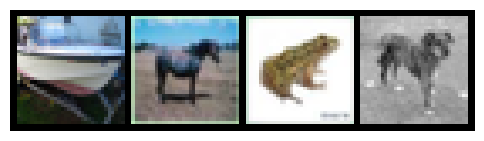

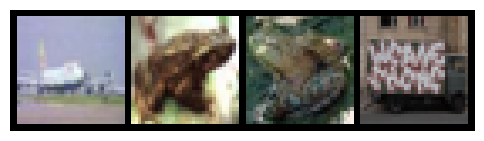

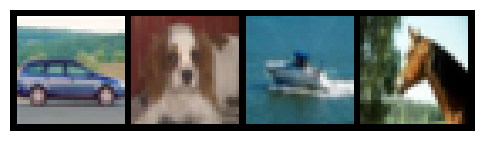

In [6]:
from torchvision.utils import make_grid
for ix in range(3):
  for images, _ in trainloader:
    plt.figure(figsize=(6,3))
    plt.axis('off')
    plt.imshow(make_grid(images, nrow=16).permute((1, 2, 0)))
    break

<h3>Clases con la definición de la Red</h3>

In [7]:
class CNN_short(nn.Module):
    def __init__(self):
        super(CNN_short, self).__init__()
        # capa convolucional (ve tensores Nx3x32x32 y devuelve tensores Nx6x28x28)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0)                             
        self.pool = nn.MaxPool2d(kernel_size=2)   # Devuelve tensores  Nx6x14x14
       
        # capa convolucional (ve tensores Nx6x14x14  y devuelve tensores Nx16x10x10)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)     
        # Capa oculta totalmente conectada. Salida a 10 clases
        
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Entran tensores Nx3x32x32 y salen Nx6x14x14
        x = self.pool(F.relu(self.conv2(x))) # Entran tensores Nx6x14x14 y salen Nx16x5x5
        # Se aplana la salida de conv2 a (batch_size, 16 * 5 * 5)
        #x = x.view(x.size(0), -1)
        x = x.view(-1, 16*5*5) # Se aplana a un vector 16x5x5 = 400
        x = F.relu(self.fc1(x)) # Capa densa de 400 -> 120
        #x = F.dropout(x, 0.5) #dropout se incluye para evitar overfitting
        x = F.relu(self.fc2(x)) # Capa densa de 120 -> 84
        #x = F.dropout(x, 0.5) #dropout se incluye para evitar overfitting
        x = self.fc3(x) # Capa densa de 84 -> 10 con la puntuación por clase
        return x

In [8]:
class CNN_long(nn.Module):
  def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # salida: N x 16 x 16 x 64

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # salida: N x 8 x 8 x 128

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # salida: N x 4 x 4 x 256

            nn.Flatten(), # Se aplana a un vector 4 x 4 x 256 = 4096
            nn.Linear(256*4*4, 1024), # Red densa FC : De 4096 -> 1024
            nn.ReLU(),
            nn.Linear(1024, 512),  # Red densa FC : De 1024 -> 512
            nn.ReLU(),
            nn.Linear(512, 10))  # Red densa FC : De 512 -> 10 con la puntuación por clase
        
  def forward(self, xb):
        return self.network(xb)

<h3>Definición de la red residual (ResNet)</h3>
La red está formada por la repetición de un bloque similar (<b>ResidualBlock</b>). El bloque está formado por una secuencia:
$$[CONV][BN][ReLU][CONV][BN]$$

Las convoluciones empleadas son todas de tamaño de filtro 3, salto 1 (en el primer bloque o layer y 2 en el resto) y padding o relleno a ceros 1. Los bloques residuales se integran en 3 capas o layers. La estructura de la red de convolución completa usando los bloques es:
$$[CONV][BN][ReLU][LAYER1][LAYER2][LAYER3][POOL][FC]$$

<p>La estructura aparece explicitamente en el cuaderno trás hacer print(model).</p>
<p>El paso [$BN$] es una Normalización (restando la media $\mu$ y dividiendo por la desviación típica $\sigma$)

Se utiliza una única capa conectada entre el vector aplanado el número de etiquetas del modelo.

La acumulación del valor residual se hace en cada bloque en la instrucción out += residual, copiandose el valor x existente al principio.

Pytorch incluye en línea unas definiciones de ResNet:

https://pytorch.org/hub/pytorch_vision_resnet/

Se puede descargar el modelo entrenado o no. El no entrenado puede utilizarse para un entrenamiento propio. Lo único tener en cuenta que el modelo devuelve hasta 1000 clases en salida. Si se usan 10 como en CIFAR10, el puntuaje máximo estará en los 10 primeros valores de esos 1000

In [9]:
# 3x3 convolution
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                     stride=stride, padding=1, bias=False)

# Residual block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

# ResNet
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 16
        self.conv = conv3x3(3, 16)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self.make_layer(block, 16, layers[0])
        self.layer2 = self.make_layer(block, 32, layers[1], 2)
        self.layer3 = self.make_layer(block, 64, layers[2], 2)
        self.avg_pool = nn.AvgPool2d(8)
        self.fc = nn.Linear(64, num_classes)

    def make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(
                conv3x3(self.in_channels, out_channels, stride=stride),
                nn.BatchNorm2d(out_channels))
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for i in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [10]:
# Se crea un modelo CNN
#if googleColaboratory:
if googleColaboratory:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #training with either cpu or cuda
    
if resNet:
    if googleColaboratory:
      model = ResNet(ResidualBlock, [2, 2, 2]).to(device)  
    else:
        model = ResNet(ResidualBlock, [2, 2, 2])
elif convolucionProfunda:
  model = CNN_long()
else:
  model = CNN_short()
if googleColaboratory:
  model = model.to(device=device) #to send the model for training on either cuda or cpu
  
print(model)

ResNet(
  (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=

<h3>Especificar la Función de Pérdida y el Optimizador</h3>
<a href="http://pytorch.org/docs/stable/nn.html#loss-functions">http://pytorch.org/docs/stable/nn.html#loss-functions</a><br/>
<a href="http://pytorch.org/docs/stable/optim.html">http://pytorch.org/docs/stable/optim.html</a>

In [11]:
import torch.optim as optim

# Se especifica la función pérdida
loss_func = nn.CrossEntropyLoss()

# Se especifica el optimizador
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
#optimizer = optim.Adam(model.parameters(), lr=0.001)

<h3>Entrenamiento de la red</h3>
Hay que observar como la pérdida en entrenamiento y validación disminuye con el tiempo; si la pérdida de validación aumenta alguna vez, indica un posible sobreajuste.

In [13]:
entrenamiento=True

In [15]:
from torch.autograd import Variable
num_epochs = 10
model.train()

lineasTraza = int(len(trainloader)/20)+1
numlineas = 0
# Train the model
for epoch in range(num_epochs):
    if not entrenamiento:
      print("No habilitada la opción de entrenamiento")
      break
    correct = 0
    total = 0
    for images, labels in trainloader:
        if googleColaboratory:
            images = images.to(device=device)
            labels = labels.to(device=device)
            
        # gives batch data, normalize x when iterate train_loader
        b_x = Variable(images)   # batch x
        b_y = Variable(labels)   # batch y
        output = model(b_x)         
        loss = loss_func(output, b_y)
        pred_y = torch.max(output, 1)[1].data.squeeze()
        correct += (pred_y == labels).sum().item()
        total +=float(labels.size(0))
        # clear gradients for this training step   
        optimizer.zero_grad()           
            
        # backpropagation, compute gradients 
        loss.backward()    
        # apply gradients             
        optimizer.step()  
        numlineas+=1
        if numlineas == lineasTraza:
            print('*', end='')
            numlineas=0
            
    print ('Época [{}], Accuracy-Entrenamiento {:.4f}'.format(epoch + 1, 100*correct/total))

*******************Época [1], Accuracy-Entrenamiento 43.8680
********************Época [2], Accuracy-Entrenamiento 63.1240
********************Época [3], Accuracy-Entrenamiento 70.0040
********************Época [4], Accuracy-Entrenamiento 74.3100
********************Época [5], Accuracy-Entrenamiento 77.4920
********************Época [6], Accuracy-Entrenamiento 79.6620
********************Época [7], Accuracy-Entrenamiento 81.3700
********************Época [8], Accuracy-Entrenamiento 82.8540
********************Época [9], Accuracy-Entrenamiento 84.1760
********************Época [10], Accuracy-Entrenamiento 85.4280


<h5>Se hace un back-up del modelo generado</h5>

In [19]:
filename = "cifar10_profunda.pt" if convolucionProfunda else "cifar10_short.pt"
if resNet: filename = "cifar10_resnet.pt"
filename = "/content/drive/My Drive/Colab Notebooks/data/" + filename if googleColaboratory else "D:/Escritorio/IA/cursos/DeepLearning/codigo/RedesNeuronales/06_CNN/CNN_animales/"+ filename
if entrenamiento:
    print("Backup al fichero=", filename)
    torch.save(model.state_dict(), filename)
    if googleColaboratory:
      goo.colab.files.download(filename)
else:
    print("No habilitado Backup del fichero")

Backup al fichero= D:/Escritorio/IA/cursos/DeepLearning/codigo/RedesNeuronales/06_CNN/CNN_animales/cifar10_resnet.pt


<h5>Recuperación del modelo desde el archivo de back-up</h5>

In [21]:
entrenamiento=False

In [22]:
device = torch.device('cpu')
if googleColaboratory:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #training with either cpu or cuda
model = CNN_long() if convolucionProfunda else CNN_short()
if resNet: model = ResNet(ResidualBlock, [2, 2, 2]).to(device) 
filename = "cifar10_profunda.pt" if convolucionProfunda else "cifar10_short.pt"
if resNet: filename = "cifar10_resnet.pt"
filename = "/content/drive/My Drive/Colab Notebooks/data/" + filename if googleColaboratory else "D:/Escritorio/IA/cursos/DeepLearning/codigo/RedesNeuronales/06_CNN/CNN_animales/"+ filename
print("Fichero cargado=", filename)
if not entrenamiento: 
  if googleColaboratory:
    model.load_state_dict(torch.load(filename, map_location=torch.device('cpu'))) #recovery trained model
  else:
    model.load_state_dict(torch.load(filename, map_location=torch.device('cpu'))) #recovery trained model
  model.eval()
  print(model)

Fichero cargado= D:/Escritorio/IA/cursos/DeepLearning/codigo/RedesNeuronales/06_CNN/CNN_animales/cifar10_resnet.pt
ResNet(
  (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

<h5>Se evalua el modelo contra el conjunto de validación</h5>

In [23]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in testloader:
        images = images.to(device=device)
        labels = labels.to(device=device)
        test_output = model(Variable(images))
        pred_y = torch.max(test_output, 1)[1].data.squeeze()
        #accuracy = (pred_y == labels).sum().item() / float(labels.size(0))
        correct += (pred_y == labels).sum().item()
        total +=float(labels.size(0))
    accuracy=100*correct/total
print('El Acierto en los 10.000 ejemplos de prueba es : %.2f %%' % accuracy)

El Acierto en los 10.000 ejemplos de prueba es : 79.61 %


<h4>Vamos a ver el aspecto de los mapas de las convoluciones</h4>
<p>El dibujo sólo está preparado para modo CPU. Una vez entrenado en GPU y volcado a fichero, recuperar en CPU y dibujar los mapas.</p>
<p>Sólo tiene un sentido el color de las imagenes. El color de los mapas no es significativo, pues no son dibujos RGB en si mismo, sino extracciones de características</p>

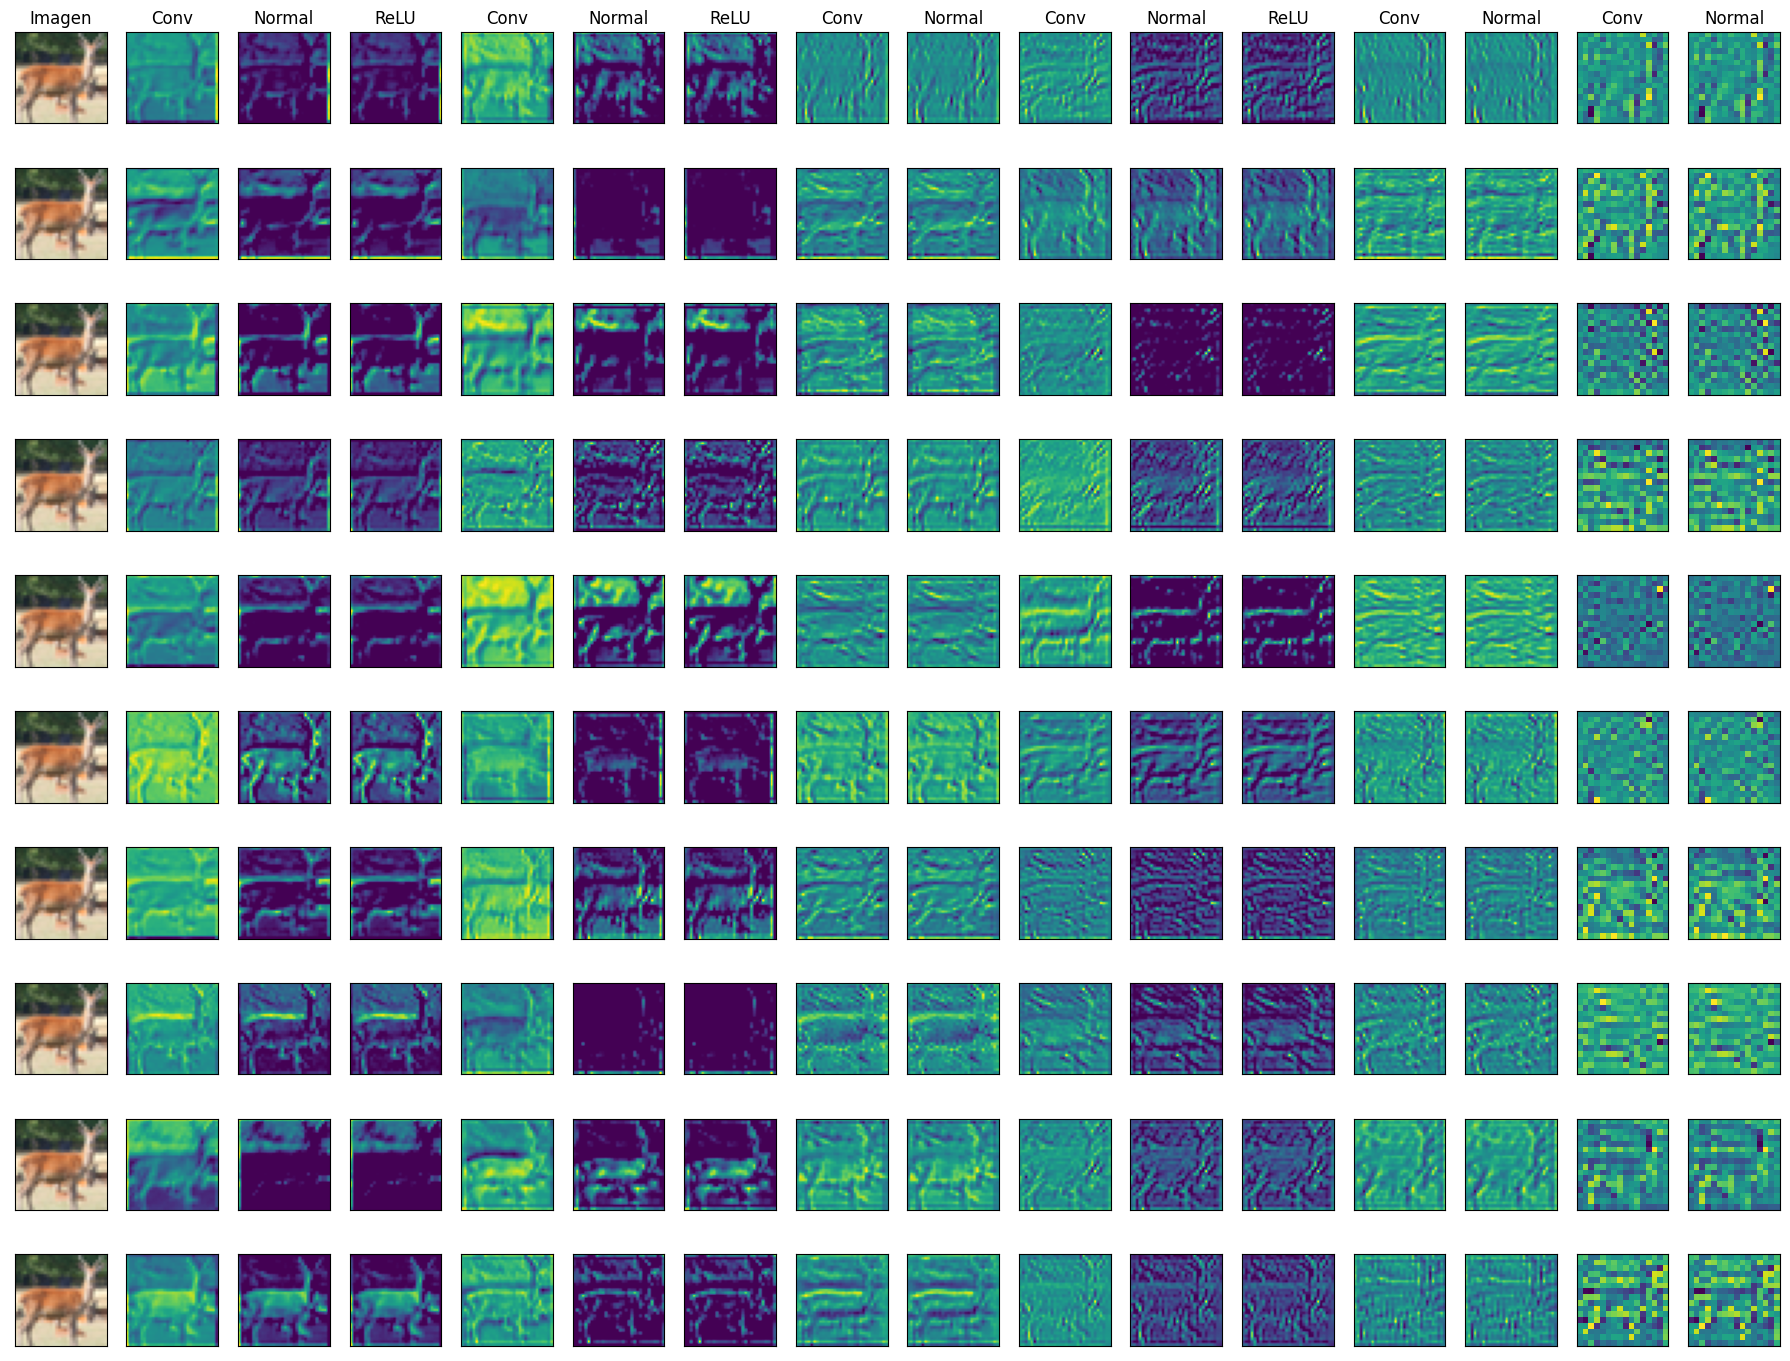

In [26]:
import matplotlib.pyplot as plt
lote_image, lote_label = next(iter(testloader))
if resNet: 
  lote_mapa1 = model.conv(lote_image)
  lote_mapa2 = model.bn(lote_mapa1)
  lote_mapa3 = model.relu(lote_mapa2)
  lote_mapa4 = model.layer1[0].conv1(lote_mapa3)
  lote_mapa5 = model.layer1[0].bn1(lote_mapa4)
  lote_mapa6 = model.layer1[0].relu(lote_mapa5)
  lote_mapa7 = model.layer1[0].conv2(lote_mapa6)
  lote_mapa8 = model.layer1[0].bn2(lote_mapa7)
  lote_mapa9 = model.layer1[1].conv1(lote_mapa8)
  lote_mapa10 = model.layer1[1].bn1(lote_mapa9)
  lote_mapa11 = model.layer1[1].relu(lote_mapa10)
  lote_mapa12 = model.layer1[1].conv2(lote_mapa11)
  lote_mapa13 = model.layer1[1].bn2(lote_mapa12)
  lote_mapa14 = model.layer2[0].conv1(lote_mapa13)
  lote_mapa15 = model.layer2[0].bn1(lote_mapa14)
elif convolucionProfunda:
  conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
  lote_mapa1 = conv1(lote_image)
  lote_mapa2 = F.relu(lote_mapa1)
  conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
  lote_mapa3 = conv2(lote_mapa2)
  lote_mapa4 = F.relu(lote_mapa3)
  pool = nn.MaxPool2d(2, 2)
  lote_mapa5 = pool(lote_mapa4)
  conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
  lote_mapa6 = conv3(lote_mapa5)
  lote_mapa7 = F.relu(lote_mapa6)
  conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
  lote_mapa8 = conv4(lote_mapa7)
  lote_mapa9 = F.relu(lote_mapa8)
  lote_mapa10 = pool(lote_mapa9)
  conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
  lote_mapa11 = conv5(lote_mapa10)
  lote_mapa12 = F.relu(lote_mapa11)
  conv6 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
  lote_mapa13 = conv6(lote_mapa12)
  lote_mapa14 = F.relu(lote_mapa13)
  lote_mapa15 = pool(lote_mapa14)
else:
  lote_mapa1 = model.conv1(lote_image)
  lote_mapa2 = F.relu(lote_mapa1)
  lote_mapa3 = model.pool(lote_mapa2)
  lote_mapa4 = model.conv2(lote_mapa3)
  lote_mapa5 = F.relu(lote_mapa4)
  lote_mapa6 = model.pool(lote_mapa5)
image = lote_image[0]  ## Se coge la primera imagen del lote
mapa1 = lote_mapa1[0]
mapa2 = lote_mapa2[0]
mapa3 = lote_mapa3[0]
mapa4 = lote_mapa4[0]
mapa5 = lote_mapa5[0]
mapa6 = lote_mapa6[0]
if convolucionProfunda or resNet:
  mapa7 = lote_mapa7[0]
  mapa8 = lote_mapa8[0]
  mapa9 = lote_mapa9[0]
  mapa10 = lote_mapa10[0]
  mapa11 = lote_mapa11[0]
  mapa12 = lote_mapa12[0]
  mapa13 = lote_mapa13[0]
  mapa14 = lote_mapa14[0]
  mapa15 = lote_mapa15[0]
label = int(lote_label[0])
numCols = 16 if convolucionProfunda or resNet else 7
fig, ax = plt.subplots(nrows=10, ncols=numCols, figsize=(18,14))
#ax = ax.flatten()
if resNet:
  literales=['Imagen', 'Conv', 'Normal', 'ReLU', 'Conv', 'Normal', 'ReLU', 'Conv', 'Normal', 'Conv', 'Normal', 'ReLU', 'Conv', 'Normal', 'Conv', 'Normal', 'ReLU']
elif convolucionProfunda:
  literales=['Imagen', 'Conv1', 'ReLU', 'Conv2', 'ReLU', 'Pool', 'Conv3', 'ReLU', 'Conv4', 'ReLU', 'Pool', 'Conv5', 'ReLU', 'Conv6', 'ReLU', 'Pool']
else:
  literales=['Imagen', 'Conv1', 'ReLU', 'Pool', 'Conv2', 'ReLU', 'Pool']
for i in range(10):
    ax[i][0].imshow(image.numpy().transpose((1, 2, 0)))
    if i < mapa1.shape[0]:
        ax[i][1].imshow(mapa1[i].detach().numpy())
        ax[i][2].imshow(mapa2[i].detach().numpy())
        ax[i][3].imshow(mapa3[i].detach().numpy())
    ax[i][4].imshow(mapa4[i].detach().numpy())
    ax[i][5].imshow(mapa5[i].detach().numpy())
    ax[i][6].imshow(mapa6[i].detach().numpy())
    if convolucionProfunda or resNet:
      ax[i][7].imshow(mapa7[i].detach().numpy())
      ax[i][8].imshow(mapa8[i].detach().numpy())
      ax[i][9].imshow(mapa9[i].detach().numpy())
      ax[i][10].imshow(mapa10[i].detach().numpy())
      ax[i][11].imshow(mapa11[i].detach().numpy())
      ax[i][12].imshow(mapa12[i].detach().numpy())
      ax[i][13].imshow(mapa13[i].detach().numpy())
      ax[i][14].imshow(mapa14[i].detach().numpy())
      ax[i][15].imshow(mapa15[i].detach().numpy())
    for j in range(numCols):
        ax[i][j].set_yticks([])
        ax[i][j].set_xticks([])
        ax[0][j].set_title(literales[j])

#fig.suptitle('Imagen tipo ' + str(clases[label]), fontsize=16)
plt.tight_layout()
plt.show()

<h5>Se visualiza la predicción</h5>

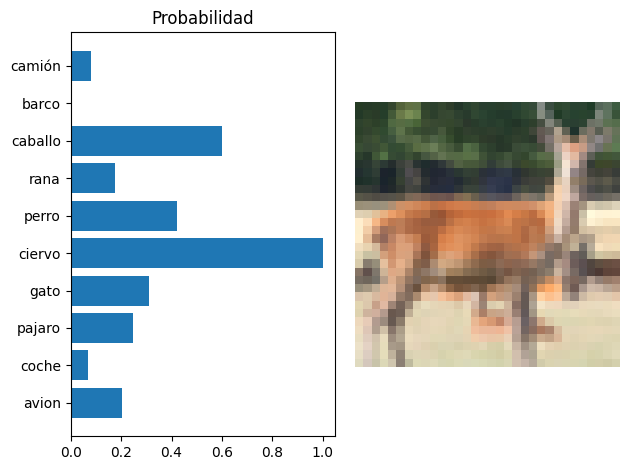

In [27]:
b_x = Variable(lote_image)   # batch x
output = model(b_x) 
fig, (ax1, ax2) = plt.subplots( ncols=2)
y=output[0].detach().numpy()
y = (y - min(y))/(max(y)-min(y))
ax2.axis('off')
ax2.imshow(image.numpy().transpose((1, 2, 0)))
ax1.set_yticks(np.arange(10))
ax1.barh(np.arange(10), y)
ax1.set_yticklabels(clases)
ax1.set_title('Probabilidad')
plt.tight_layout()

<h4>Se prueba con fotos externas</h4>

In [28]:
def importImagesFromPath(my_directory, imageSize):
    transform = transforms.Compose([
        transforms.Resize(imageSize),
        transforms.CenterCrop(imageSize),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    _first=True
    filesName = []
    for file in glob.glob(my_directory+"/*.jpg"):
        PILimag = Image.open(file)
        tensorImag = transform(PILimag).unsqueeze(0) ## Se transforma en tensor y se añade 1 dimensión
        filesName.append(file)
        if _first:
            loteImag = tensorImag
            _first = False
        else:
            loteImag = torch.cat((loteImag, tensorImag), 0)
    return loteImag, filesName

In [61]:
imagAnimal, filesName = importImagesFromPath("./animalesTest", 32)
b_x = Variable(imagAnimal)   # batch x
predict = model(b_x)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


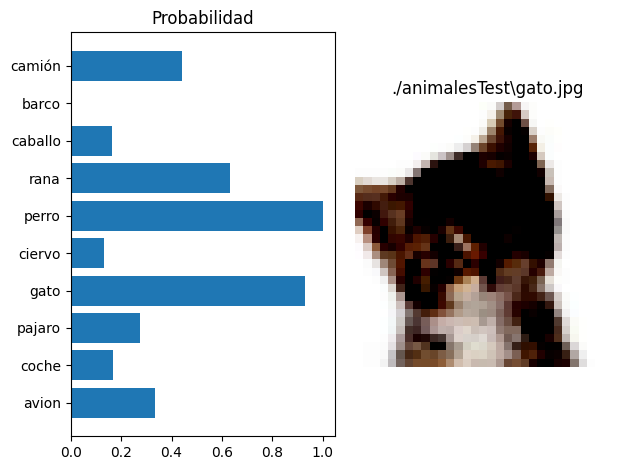

In [64]:
iTest=8
fig, (ax1, ax2) = plt.subplots( ncols=2)
y=predict[iTest].detach().numpy()
y = (y - min(y))/(max(y)-min(y))
ax2.axis('off')
ax2.imshow(imagAnimal[iTest].numpy().transpose((1, 2, 0)))
ax2.set_title(filesName[iTest])
ax1.set_title('Probabilidad')
ax1.set_yticks(np.arange(10))
ax1.barh(np.arange(10), y)
ax1.set_yticklabels(clases)
plt.tight_layout()